# 🧪 因果推断：分级闯关测试 (Causal Inference Gym)

**对应周**: Week 3 - Causal Inference
**目标**: 通过 3 个关卡 (Level 1-3)，彻底掌握因果推断的核心直觉。不依赖复杂的库，回归数学本质。

> **注意**: 本练习特例使用 **模拟数据 (Simulated Data)**，旨在提供"上帝视角" (True Effect) 以验证你的计算结果。这是学习因果推断原理的最佳方式。

## 📚 模块 0: 函数加油站 (Function Cheat Sheet)

在开始闯关前，先熟悉一下今天的武器库。

| 函数/方法 | 大白话解释 | 常用参数 | SQL 类比 |
| :--- | :--- | :--- | :--- |
| `np.random.normal()` | 生成符合正态分布的随机数 (造数据用) | `loc`(均值), `scale`(标准差) | `RAND()` |
| `sns.lmplot()` | 画散点图 + 回归线，一眼看出相关性 | `x`, `y`, `hue`(颜色/分组) | - |
| `LogisticRegression()` | 逻辑回归，用来算 PSM 的倾向性得分 | `fit(X, y)`, `predict_proba(X)` | 简单的分类模型 |
| `df.sample()` | 随机抽样 | `n`(个数), `random_state`(种子) | `ORDER BY RAND() LIMIT N` |

## 🗺️ 模块 1: 概念映射 (SQL Analogy)

用你熟悉的 SQL 思维来理解神神秘秘的因果推断：

### 1. Confounder (混淆变量)
你以为 `X -> Y`，其实是 `Z -> X` 且 `Z -> Y`。
- **SQL 类比**: 就好比你只 `GROUP BY X` 看 `AVG(Y)`，结果被 `Z` 分布不均骗了。你必须 `GROUP BY X, Z` 才能看到真相。

### 2. DID (双重差分)
消除时间带来的自然增长。
- **SQL 类比**: 
  ```sql
  -- 两次做差
  (AVG(Y) WHERE Group='Treat' AND Time='Post' - AVG(Y) WHERE Group='Treat' AND Time='Pre')
  -
  (AVG(Y) WHERE Group='Control' AND Time='Post' - AVG(Y) WHERE Group='Control' AND Time='Pre')
  ```

### 3. PSM (倾向性得分匹配)
在控制组里找一个"世另我"。
- **SQL 类比**: 
  ```sql
  SELECT * 
  FROM Treatment t 
  LEFT JOIN Control c 
  ON ABS(t.propensity_score - c.propensity_score) < 0.01 -- 模糊匹配，找分身
  ```

In [1]:
# 🛠️ 环境准备
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression

# 设置中文字体 (防止乱码)
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

np.random.seed(42) # 固定随机种子，保证每次运行结果一致

## 🏭 模块 2: 数据准备 (Data Simulation)

我们构建三个场景的模拟数据。请运行以下代码生成数据。

In [2]:
# === 场景 1: 冰淇淋与溺水 (Confounder) ===
def get_l1_data(n=200):
    temp = np.random.normal(30, 5, n)  
    ice_cream = 10 * temp + np.random.normal(0, 10, n)
    drowning = 0.5 * temp + np.random.normal(0, 2, n)
    return pd.DataFrame({'Temperature': temp, 'IceCream': ice_cream, 'Drowning': drowning})

# === 场景 2: 城市新政 (DID) ===
def get_l2_data():
    data = [
        {'Group': 'Control', 'Period': 'Pre', 'Value': 100},
        {'Group': 'Control', 'Period': 'Post', 'Value': 110},  # +10 自然增长
        {'Group': 'Treatment', 'Period': 'Pre', 'Value': 100},
        {'Group': 'Treatment', 'Period': 'Post', 'Value': 160}, # +60 = (+10 自然 + 50 政策)
    ]
    return pd.DataFrame(data)

# === 场景 3: 会员购买 (PSM) ===
def get_l3_data(n=1000):
    income = np.random.normal(5000, 2000, n)
    income = np.maximum(income, 1000)
    prob_member = 1 / (1 + np.exp(-(income - 5000) / 1000)) # 收入越高越买会员
    is_member = np.random.binomial(1, prob_member)
    # 真实效应 = 200
    spend = (income * 0.1) + (is_member * 200) + np.random.normal(0, 50, n)
    return pd.DataFrame({'Income': income, 'IsMember': is_member, 'Spend': spend})

df_l1 = get_l1_data()
df_l2 = get_l2_data()
df_l3 = get_l3_data()

## ⚔️ 模块 3: 分级挑战 (Levels)

### Level 1: 寻找第三者 (Spurious Correlation)
**任务**: 证明 "冰淇淋" 和 "溺水" 只是伪相关。

In [ ]:
# 挑战 1: 画图
# 1. 画 sns.lmplot(x='IceCream', y='Drowning') 看似正相关
# 2. 加上 hue='Temperature' (这时你会发现，同一温度下，线变平了)

# 你的代码:
sns.lmplot(data=df_l1,x='IceCream', y='Drowning')
# sns.lmplot(data=df_l1,x='IceCream', y='Drowning',hue='Temperature')


# ---------------------------------------------------------
# 修正后的代码：
# 1. 对连续变量 Temperature 进行分箱 (Binning)，生成 'Temp_Group'
# 2. 将 hue 参数指向分箱后的分类变量
# ---------------------------------------------------------

# 将温度分为 'Low', 'Medium', 'High' 三个等级
df_l1['Temp_Group'] = pd.cut(df_l1['Temperature'], bins=7)

# 使用 Temp_Group 作为 hue (颜色分类)，而不是原始的 Temperature
sns.lmplot(data=df_l1, x='IceCream', y='Drowning', hue='Temp_Group')



### Level 2: 手算 DID (Manual Caluculation)
**任务**: 算出 Policy 的真实效应 (True Effect)。已知答案是 50。

In [26]:
# 挑战 2: 计算
# 公式: (Treat_Post - Treat_Pre) - (Control_Post - Control_Pre)
# df_l2['Treatment_Effect'] = df_l2['Treatment_Post'] - df_l2['Treatment_Pre'] - (df_l2['Control_Post'] - df_l2['Control_Pre'])
# 你的代码:
df_l2
count_tb = df_l2.pivot_table(
    index='Period',
    columns='Group',
    values='Value',
    aggfunc='max'
).reset_index()

count_tb['effect'] = count_tb['Treatment'] - count_tb['Control']
# df_l2['true_effect'] = df_l2
count_tb
true_effect = count_tb.loc[count_tb['Period'] == 'Post']['effect'].values[0] - count_tb.loc[count_tb['Period'] == 'Pre']['effect'].values[0] 
true_effect

# df_l2

# true_effect_control = df_l2.loc[(df_l2['Group'] == 'Control') & (df_l2['Period'] == 'Post')]['Value']- df_l2.loc[(df_l2['Group'] == 'Treatment') & (df_l2['Period'] == 'Post')]['Value']
# true_effect_treatement = df_l2.loc[(df_l2['Group'] == 'Control') & (df_l2['Period'] == 'Post')]['Value']- df_l2.loc[(df_l2['Group'] == 'Treatment') & (df_l2['Period'] == 'Post')]['Value']
# true_effect_control

treat_post = df_l2.loc[(df_l2['Group']=='Treatment') & (df_l2['Period']=='Post'), 'Value'].values[0]
treat_pre  = df_l2.loc[(df_l2['Group']=='Treatment') & (df_l2['Period']=='Pre'), 'Value'].values[0]
ctrl_post  = df_l2.loc[(df_l2['Group']=='Control') & (df_l2['Period']=='Post'), 'Value'].values[0]
ctrl_pre   = df_l2.loc[(df_l2['Group']=='Control') & (df_l2['Period']=='Pre'), 'Value'].values[0]

did = (treat_post - treat_pre) - (ctrl_post - ctrl_pre)
print(f"DID Effect: {did}")  # 应该输出 50



DID Effect: 50


### Level 3: 徒手 PSM (Matching Logic)
**任务**: 消除收入带来的 Selection Bias，算出接近 200 的真实效应。

In [ ]:
# 挑战 3: 
# 1. Fit LogisticRegression, 得到 df_l3['score']
# 2. 对于每个 Member (Treat)，找一个分数最近的 Non-Member (Control)
# 3. 算差值平均
df_l3
# 你的代码:

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors
import pandas as pd 

model = LogisticRegression()
x = df_l3.drop(columns=['IsMember'])
y = df_l3['IsMember']
model.fit(x, y)
df_l3['score'] = model.predict_proba(x)[:, 1]
df_l3


,Income,IsMember,Spend,score
0,6513.977233,1,935.070328,1.000000
1,3155.669352,0,382.589988,0.017789
2,6739.211840,1,808.942122,0.986508
3,7711.275718,1,1012.614193,0.999998
4,5826.869806,1,823.256808,0.999992
...,...,...,...,...
995,2980.538591,0,277.833988,0.000018
996,6238.308522,1,848.402325,0.999980
997,9114.990939,1,1139.987112,0.999999
998,5041.587415,1,713.932828,0.999825


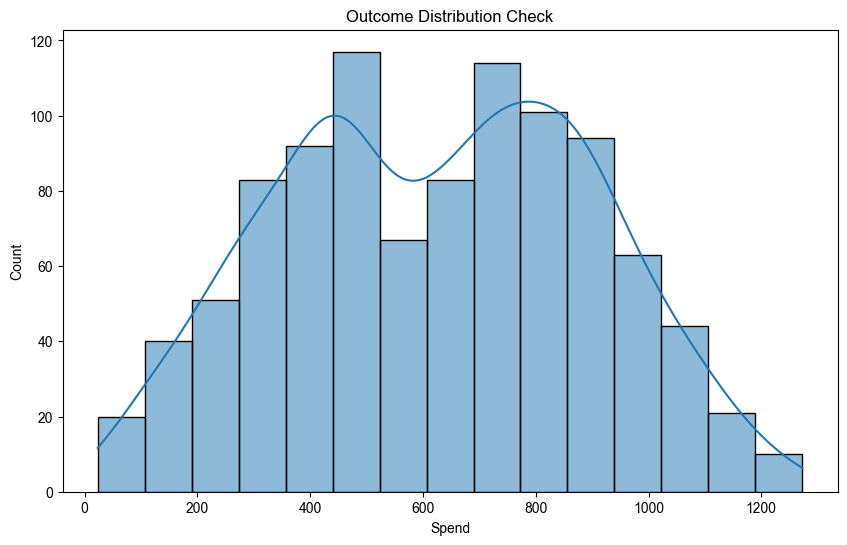

Skewness: -0.01


In [35]:
# 分布检查代码 (Distribution Check)
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. 绘制直方图 + KDE 曲线
plt.figure(figsize=(10, 6))
sns.histplot(df_l3['Spend'], kde=True)
plt.title('Outcome Distribution Check')
plt.show()

# 2. 偏度检查 (Skewness)
skewness = df_l3['Spend'].skew()
print(f"Skewness: {skewness:.2f}")
if skewness > 1:
    print("Tip: 右偏严重，建议尝试 np.log1p(Y) 变换")

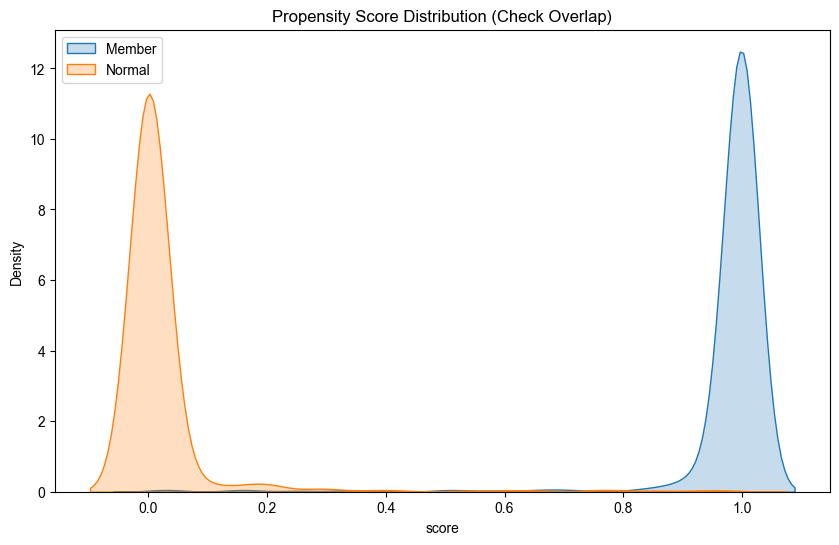

In [30]:
# 1. 绘制 PS 分布图 (必须！)
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.kdeplot(df_l3[df_l3['IsMember']==1]['score'], label='Member', fill=True)
sns.kdeplot(df_l3[df_l3['IsMember']==0]['score'], label='Normal', fill=True)
plt.title('Propensity Score Distribution (Check Overlap)')
plt.legend()
plt.show()

# 2. 检查被重复匹配的用户
# print(matched_control['user_id'].value_counts().head())

In [43]:
# 只保留 Common Support 区域内的样本

min_ps = df_l3[df_l3['IsMember']==0]['score'].min()
max_ps = df_l3[df_l3['IsMember']==0]['score'].max()

df_trimmed = df_l3[
    (df_l3['score'] >= min_ps) & 
    (df_l3['score'] <= max_ps)
]
print(f"Trimmed: {len(df_l3)} -> {len(df_trimmed)} samples")



# 2. 执行匹配 (简单版 - 1对1匹配)
treated = df_trimmed[df_trimmed['IsMember'] == 1]
control = df_trimmed[df_trimmed['IsMember'] == 0]

# 在 Control 组中找 Treated 组的邻居
nn = NearestNeighbors(n_neighbors=1)
nn.fit(control[['score']])
distances, indices = nn.kneighbors(treated[['score']])

# 获取匹配后的 Control 组数据
matched_control = control.iloc[indices.flatten()]

# 3. 计算 ATE (Average Treatment Effect)
ate = treated['Spend'].mean() - matched_control['Spend'].mean()
print(f"PSM Estimated Effect: {ate:.4f}")



Trimmed: 1000 -> 938 samples
PSM Estimated Effect: 198.1722


In [40]:
# 在截断后的数据上重新跑回归
import statsmodels.formula.api as smf
model_trimmed = smf.ols('Spend ~ IsMember', data=df_trimmed).fit()
model_trimmed.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Spend   R-squared:                       0.197
Model:                            OLS   Adj. R-squared:                  0.196
Method:                 Least Squares   F-statistic:                     124.7
Date:                Tue, 24 Feb 2026   Prob (F-statistic):           4.73e-26
Time:                        10:00:56   Log-Likelihood:                -3298.7
No. Observations:                 510   AIC:                             6601.
Df Residuals:                     508   BIC:                             6610.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    384.2362      7.306     52.595      0.000     369.883     398.589
IsMember     253.1150     22.662     11.169      0.000     208.592     297.638
==============================================================================
Omnibus:                        1.323   Durbin-Watson:                   1.957
Prob(Omnibus):                  0.516   Jarque-Bera (JB):                1.382
Skew:                           0.120   Prob(JB):                        0.501
Kurtosis:                       2.916   Cond. No.                         3.32
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## 💡 模块 4: 参考答案 (Solutions)

In [ ]:
# === Level 1 参考 ===
sns.lmplot(data=df_l1, x='IceCream', y='Drowning', hue='Temperature', legend=True)
plt.title('Controlling for Temperature')

In [ ]:
# === Level 2 参考 ===
treat_post = 160
treat_pre = 100
control_post = 110
control_pre = 100
did = (treat_post - treat_pre) - (control_post - control_pre)
print(f"DID Effect: {did}")

In [41]:
# === Level 3 参考 ===
# 1. Score
lr = LogisticRegression()
lr.fit(df_l3[['Income']], df_l3['IsMember'])
df_l3['score'] = lr.predict_proba(df_l3[['Income']])[:, 1]

# 2. Match
treated = df_l3[df_l3.IsMember == 1]
control = df_l3[df_l3.IsMember == 0]

matched_diffs = []
for idx, t_row in treated.iterrows():
    # 暴力找最近邻 (实际生产用 NearestNeighbors)
    closest_idx = (control['score'] - t_row['score']).abs().idxmin()
    c_row = control.loc[closest_idx]
    matched_diffs.append(t_row['Spend'] - c_row['Spend'])

att = np.mean(matched_diffs)
print(f"Estimated ATT: {att:.2f} (True: 200)")

Estimated ATT: 208.58 (True: 200)
